In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer


In [114]:
df = pd.read_excel('online_retail_II.xlsx')

In [115]:
eda_df = df.copy()

In [116]:
eda_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [117]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1048575 non-null  object        
 1   StockCode    1048575 non-null  object        
 2   Description  1044203 non-null  object        
 3   Quantity     1048575 non-null  int64         
 4   InvoiceDate  1048575 non-null  datetime64[ns]
 5   Price        1048575 non-null  float64       
 6   Customer ID  811893 non-null   float64       
 7   Country      1048575 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 64.0+ MB


In [118]:
eda_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.048575e+06,1048575,1.048575e+06,811893.000000
mean,9.957525e+00,2010-12-27 19:44:22.911264768,4.627346e+00,15324.712265
min,-7.421500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-05 13:46:00,1.250000e+00,13971.000000
50%,3.000000e+00,2010-12-06 09:58:00,2.100000e+00,15260.000000
75%,1.000000e+01,2011-07-12 16:20:00,4.150000e+00,16795.000000
max,7.421500e+04,2011-12-04 13:15:00,3.897000e+04,18287.000000
std,1.335187e+02,NaN,1.228024e+02,1697.033034


In [119]:
eda_df.isnull().sum()

Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64

In [120]:
eda_df = eda_df.dropna(subset=['Customer ID'])

In [121]:
eda_df.duplicated().sum()

26294

In [122]:
eda_df.drop_duplicates(inplace=True)

In [123]:
eda_df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

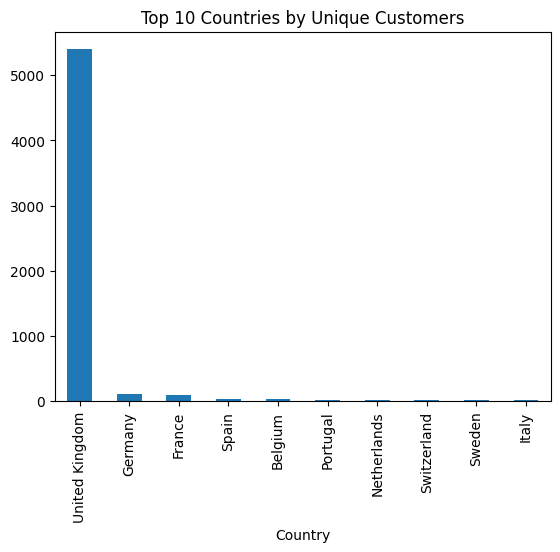

In [124]:
eda_df['TotalPrice'] = eda_df['Quantity'] * eda_df['Price']

Country_data = eda_df.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False).head(10)
Country_data.plot(kind='bar', title='Top 10 Countries by Unique Customers')
plt.show()

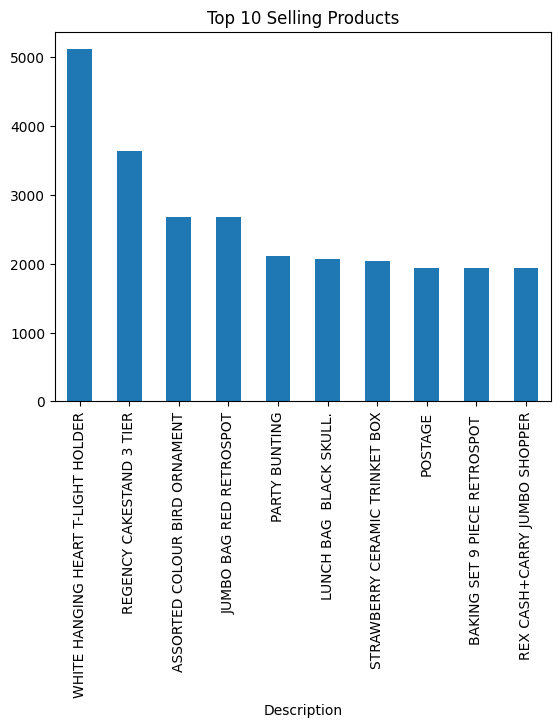

In [125]:
top_products = eda_df['Description'].value_counts().head(10)
top_products.plot(kind='bar', title='Top 10 Selling Products')
plt.show()

In [126]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 785599 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      785599 non-null  object        
 1   StockCode    785599 non-null  object        
 2   Description  785599 non-null  object        
 3   Quantity     785599 non-null  int64         
 4   InvoiceDate  785599 non-null  datetime64[ns]
 5   Price        785599 non-null  float64       
 6   Customer ID  785599 non-null  float64       
 7   Country      785599 non-null  object        
 8   TotalPrice   785599 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.9+ MB


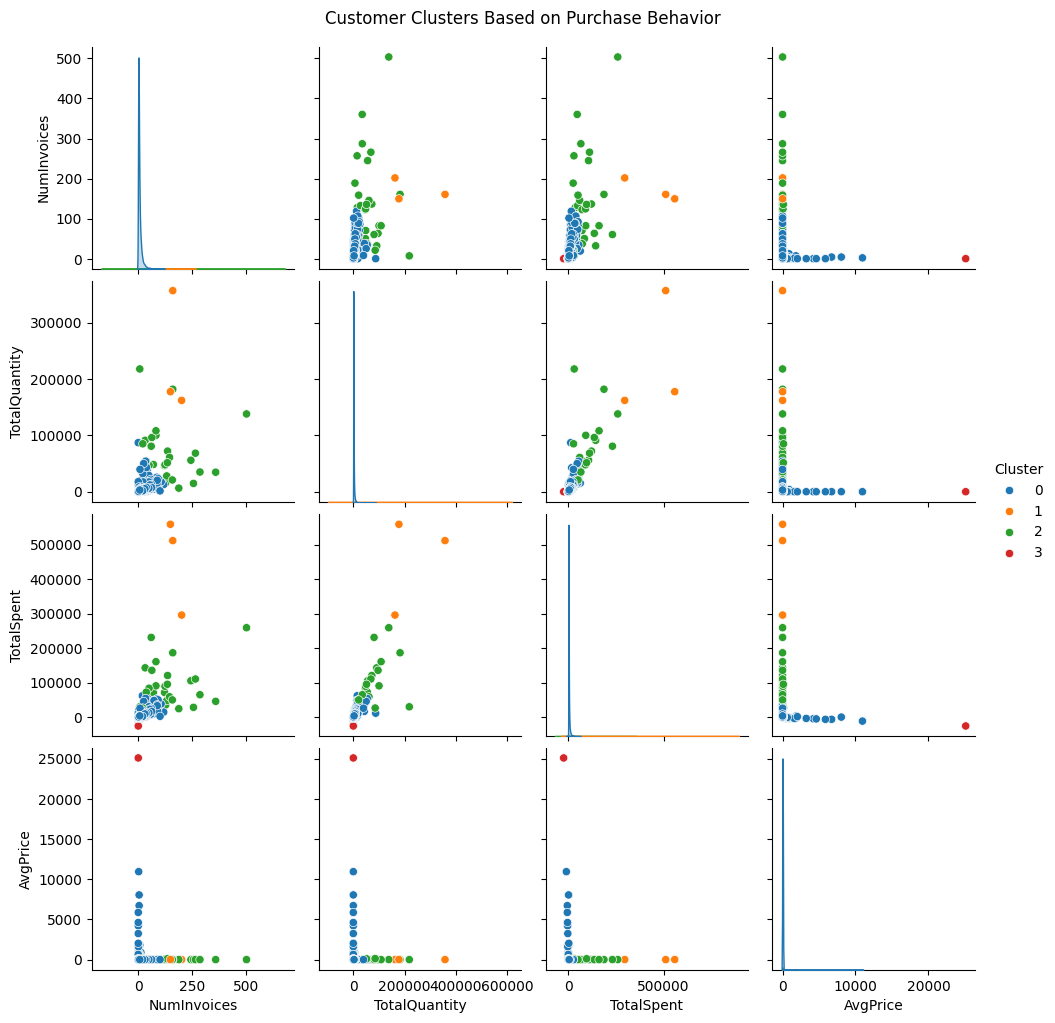

In [127]:
customer_features = eda_df.groupby('Customer ID').agg({
    'Invoice' : 'nunique',
    'Quantity' : 'sum',
    'TotalPrice' : 'sum',
    'Price' : 'mean'
    }).reset_index()         

# Corrected column names
customer_features.columns = ['CustomerID', 'NumInvoices', 'TotalQuantity', 'TotalSpent', 'AvgPrice']

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features[['NumInvoices', 'TotalQuantity', 'TotalSpent', 'AvgPrice']])

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

sns.pairplot(
    customer_features,
    hue='Cluster',
    vars=['NumInvoices', 'TotalQuantity', 'TotalSpent', 'AvgPrice'],
    palette='tab10'
)

plt.suptitle("Customer Clusters Based on Purchase Behavior", y=1.02)
plt.show()


In [128]:
import datetime as dt

# Latest date for Recency
snapshot_date = eda_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = eda_df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())


             Recency  Frequency  Monetary
Customer ID                              
12346.0          321         17    -51.74
12347.0           35          7   4696.71
12348.0           71          5   2019.40
12349.0           14          5   4404.54
12350.0          305          1    334.40


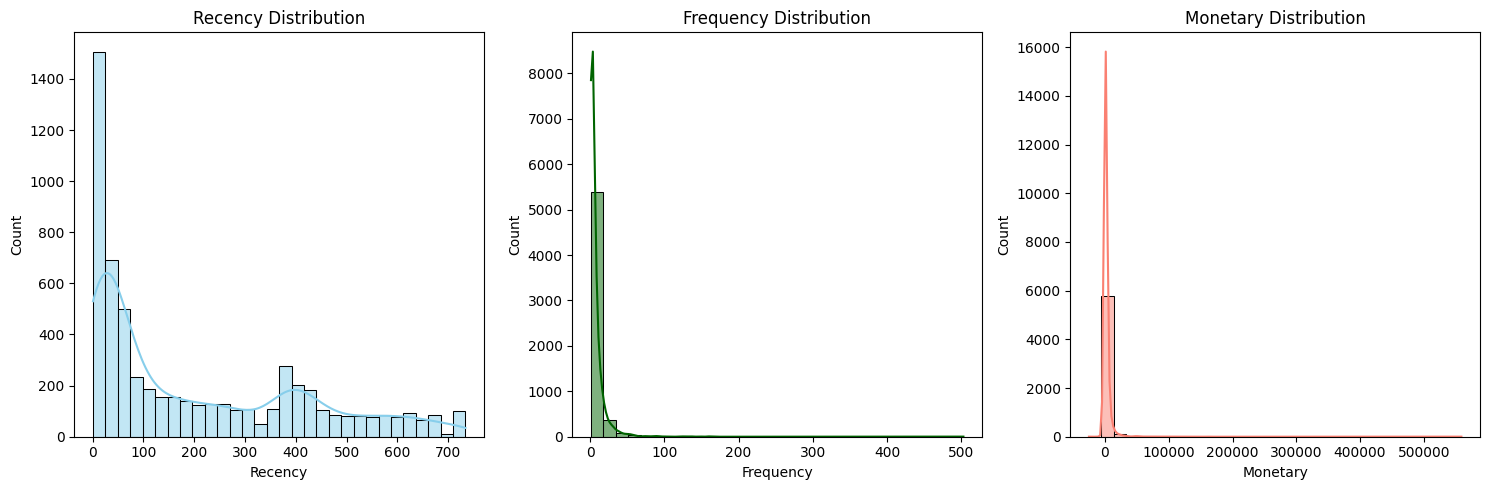

In [129]:
plt.figure(figsize=(15, 5))

# Recency
plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True, color='skyblue')
plt.title('Recency Distribution')

# Frequency
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30, kde=True, color='darkgreen')
plt.title('Frequency Distribution')

# Monetary
plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30, kde=True, color='salmon')
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()


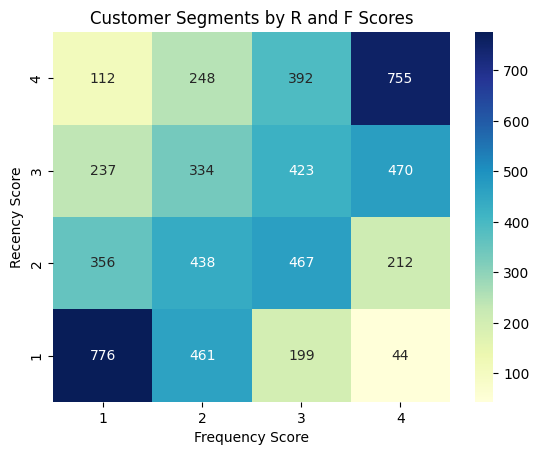

In [130]:
# Create R, F, M scores
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine into segment
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)

# Heatmap
rfm_heatmap = rfm.groupby(['R_score', 'F_score']).size().unstack()
sns.heatmap(rfm_heatmap, cmap='YlGnBu', annot=True, fmt="d")
plt.title('Customer Segments by R and F Scores')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()


In [131]:
rfm['RFM_Score'].value_counts()

RFM_Score
12    652
6     637
8     635
7     601
5     591
4     584
3     568
9     567
11    545
10    544
Name: count, dtype: int64

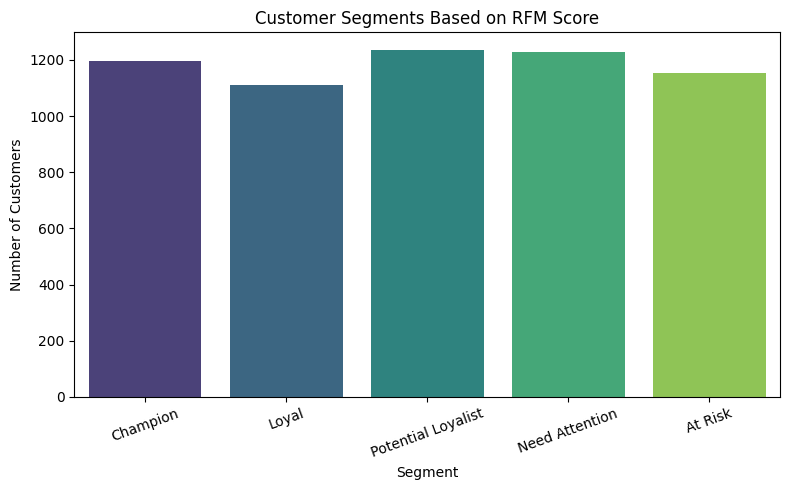

In [132]:
# Step 1: Segment RFM scores into 5 groups using pd.cut
rfm['Segment'] = pd.cut(rfm['RFM_Score'],
                        bins=[0, 4, 6, 8, 10, 12],
                        labels=['At Risk', 'Need Attention', 'Potential Loyalist', 'Loyal', 'Champion'])

plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Segment',
              order=['Champion', 'Loyal', 'Potential Loyalist', 'Need Attention', 'At Risk'],
              palette='viridis')

plt.title('Customer Segments Based on RFM Score')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [133]:
eda_df['TotalPrice'] = eda_df['Quantity'] * eda_df['Price']

snapshot_date = eda_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Calculation
rfm = eda_df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm_filtered = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]

# Pipeline and model
numeric_features = ['Recency', 'Frequency', 'Monetary']
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features)])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=4, random_state=42))
])

# Fit model
pipeline.fit(rfm_filtered)
rfm_filtered['Cluster'] = pipeline.named_steps['clusterer'].labels_


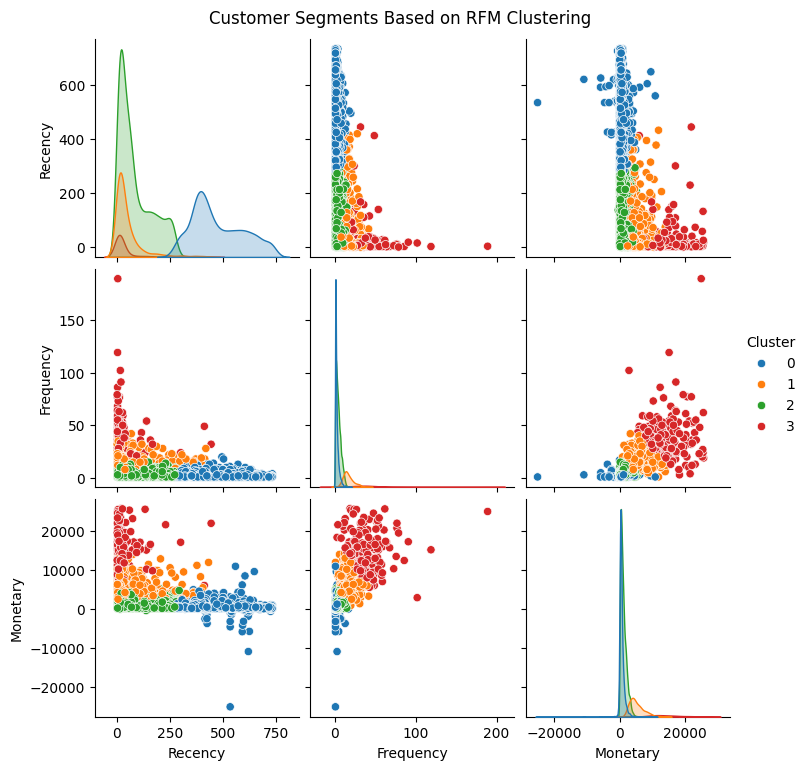

In [134]:
sns.pairplot(rfm_filtered.reset_index(), hue='Cluster', vars=numeric_features, palette='tab10')
plt.suptitle("Customer Segments Based on RFM Clustering", y=1.02)
plt.show()


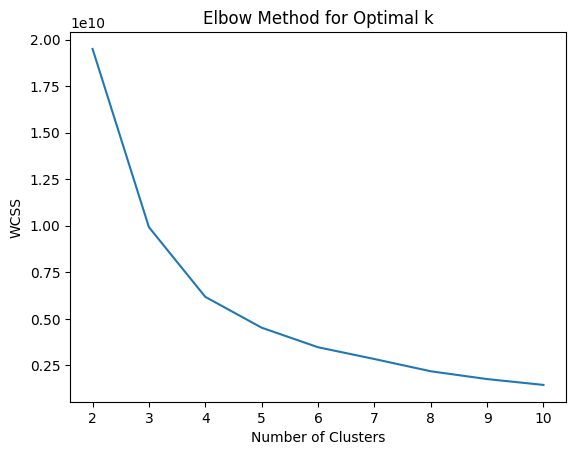

In [156]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS (within-cluster sum of squares) for different k values
wcss = []
for k in range(2, 11):  # Try different values of k (1 to 10)
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_filtered[numeric_features])
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss)
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


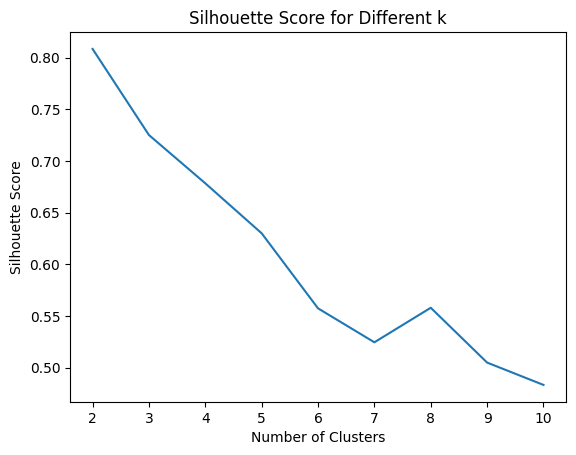

In [142]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different k values
sil_scores = []
for k in range(2, 11):  # k should be >= 2
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_filtered[numeric_features])
    sil_scores.append(silhouette_score(rfm_filtered[numeric_features], kmeans.labels_))

plt.plot(range(2, 11), sil_scores)
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [144]:
eval_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=2, random_state=42))
])

eval_pipeline.fit(rfm_filtered)
rfm_filtered['cluster'] = eval_pipeline.named_steps['clusterer'].labels_



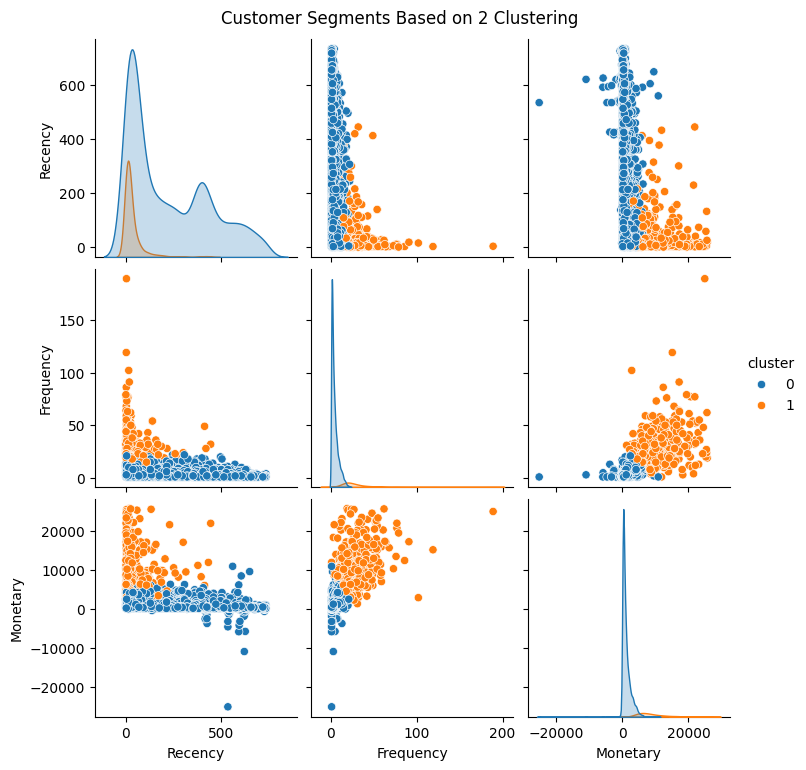

In [146]:
sns.pairplot(rfm_filtered.reset_index(), hue='cluster', vars=numeric_features, palette='tab10')
plt.suptitle("Customer Segments Based on 2 Clustering", y=1.02)
plt.show()